### Import Libraries

In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

import torch
import torchvision
from torchvision import transforms
import torch.nn as nn

# Моделі YOLOv8:
#  'yolov8n.pt' (nano) - найшвидша, найменш точна
#  'yolov8s.pt' (small) - швидка
#  'yolov8l.pt' (large) - точна, повільніша
#  'yolov8x.pt' (xlarge) - найточніша, найповільніша

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### YOLOv8

In [4]:
model = YOLO('yolov8l.pt')  # Завантаження попередньо навченого моделі YOLOv8s

class_names = ['car','bus','truck','bycle','motorcycle']  # Визначення класів об'єктів для виявлення

### Fine-tuning YOLOv8 on Custom Dataset

In [ ]:
model.train(
    data='data.yaml',  # Шлях до файлу з описом датасету
    epochs=50,         # Кількість епох для навчання
    batch=16,         # Розмір батчу
    imgsz=640,
    device="cuda",
    name='yolov8l_custom',  # Ім'я експерименту для збереження результатів
)

Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8l_custom6, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretraine

RuntimeError: Dataset 'data.yaml' error ❌ 'data.yaml' does not exist

In [ ]:
metrics = model.val() 
print(metrics)

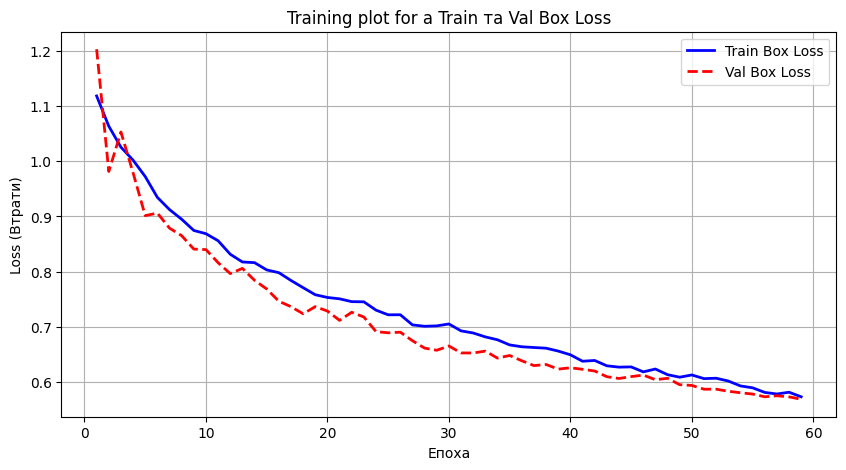

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Вкажіть шлях до вашого файлу results.csv
csv_path = r'E:\personalproject\bachelor\model\plot-result\yolo\results.csv'
df = pd.read_csv(csv_path)

# YOLOv8 часто залишає пробіли в назвах колонок, тому їх треба прибрати
df.columns = df.columns.str.strip()

# Створюємо графік
plt.figure(figsize=(10, 5))

# Будуємо графіки втрат для Train та Val (наприклад, box_loss)
plt.plot(df['epoch'], df['train/box_loss'], label='Train Box Loss', color='blue', linewidth=2)
plt.plot(df['epoch'], df['val/box_loss'], label='Val Box Loss', color='red', linewidth=2, linestyle='--')

plt.title('Training plot for a Train та Val Box Loss')
plt.xlabel('Епоха')
plt.ylabel('Loss (Втрати)')
plt.legend()
plt.grid(True)

# Зберігаємо або показуємо
plt.savefig('combined_loss.png')
plt.show()